Colab is making it easier than ever to integrate powerful Generative AI capabilities into your projects. We are launching public preview for a simple and intuitive Python library (google.colab.ai) to access state-of-the-art language models directly within Colab environments. All users have free access to most popular LLMs, while paid users have access to a wider selection of models. This means users can spend less time on configuration and set up and more time bringing their ideas to life. With just a few lines of code, you can now perform a variety of tasks:
- Generate text
- Translate languages
- Write creative content
- Categorize text

Happy Coding!


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb)

In [ ]:
"

In [ ]:
# @title List available models
from google.colab import ai

ai.list_models()

['google/gemini-2.0-flash',
 'google/gemini-2.0-flash-lite',
 'google/gemini-2.5-flash',
 'google/gemini-2.5-flash-lite',
 'google/gemini-2.5-pro',
 'google/gemma-3-12b',
 'google/gemma-3-1b',
 'google/gemma-3-27b',
 'google/gemma-3-4b']

Choosing a Model
The model names give you a hint about their capabilities and intended use:

Pro: These are the most capable models, ideal for complex reasoning, creative tasks, and detailed analysis.

Flash: These models are optimized for high speed and efficiency, making them great for summarization, chat applications, and tasks requiring rapid responses.

Gemma: These are lightweight, open-weight models suitable for a variety of text generation tasks and are great for experimentation.

In [ ]:
# @title Simple batch generation example
# Only text-to-text input/output is supported
from google.colab import ai

response = ai.generate_text("What is the capital of France?")
print(response)

The capital of France is **Paris**.



In [ ]:
# @title Choose a different model
from google.colab import ai

response = ai.generate_text("What is the capital of England", model_name='google/gemini-2.0-flash-lite')
print(response)

The capital of England is **London**.



For longer text generations, you can stream the response. This displays the output token by token as it's generated, rather than waiting for the entire response to complete. This provides a more interactive and responsive experience. To enable this, simply set stream=True.

In [ ]:
# @title Simple streaming example
from google.colab import ai

stream = ai.generate_text("Tell me a short story.", stream=True)
for text in stream:
  print(text, end='')

The lighthouse keeper, Silas, was a man of routine. Every night, for fifty years, he'd lit the lamp, a beacon against the treacherous rocks that gnawed at the coastline. The sea was his companion, his enemy, and his only confidante. He knew its moods better than his own.

One stormy night, the wind howled like a banshee. The waves crashed against the tower, shaking it to its core. Silas, clinging to the railing, felt a fear he hadn't experienced in decades. This wasn't just a storm; this was a monster.

Suddenly, a small, wooden boat, tossed about like a toy, appeared in the raging sea. He squinted, his heart leaping into his throat. A child. Alone.

Ignoring the raging tempest, Silas raced down the winding stairs, his old bones protesting with every step. He launched his small rescue boat, a fragile craft against the fury of the storm.

Fighting the waves, he reached the child. A girl, no older than seven, clung to the wreckage, her face white with terror. With a strength born of desp

In [ ]:
#@title Text formatting setup
#code is not necessary for colab.ai, but is useful in fomatting text chunks
import sys

class LineWrapper:
    def __init__(self, max_length=80):
        self.max_length = max_length
        self.current_line_length = 0

    def print(self, text_chunk):
        i = 0
        n = len(text_chunk)
        while i < n:
            start_index = i
            while i < n and text_chunk[i] not in ' \n': # Find end of word
                i += 1
            current_word = text_chunk[start_index:i]

            delimiter = ""
            if i < n: # If not end of chunk, we found a delimiter
                delimiter = text_chunk[i]
                i += 1 # Consume delimiter

            if current_word:
                needs_leading_space = (self.current_line_length > 0)

                # Case 1: Word itself is too long for a line (must be broken)
                if len(current_word) > self.max_length:
                    if needs_leading_space: # Newline if current line has content
                        sys.stdout.write('\n')
                        self.current_line_length = 0
                    for char_val in current_word: # Break the long word
                        if self.current_line_length >= self.max_length:
                            sys.stdout.write('\n')
                            self.current_line_length = 0
                        sys.stdout.write(char_val)
                        self.current_line_length += 1
                # Case 2: Word doesn't fit on current line (print on new line)
                elif self.current_line_length + (1 if needs_leading_space else 0) + len(current_word) > self.max_length:
                    sys.stdout.write('\n')
                    sys.stdout.write(current_word)
                    self.current_line_length = len(current_word)
                # Case 3: Word fits on current line
                else:
                    if needs_leading_space:
                        # Define punctuation that should not have a leading space
                        # when they form an entire "word" (token) following another word.
                        no_leading_space_punctuation = {
                            ",", ".", ";", ":", "!", "?",        # Standard sentence punctuation
                            ")", "]", "}",                     # Closing brackets
                            "'s", "'S", "'re", "'RE", "'ve", "'VE", # Common contractions
                            "'m", "'M", "'ll", "'LL", "'d", "'D",
                            "n't", "N'T",
                            "...", "…"                          # Ellipses
                        }
                        if current_word not in no_leading_space_punctuation:
                            sys.stdout.write(' ')
                            self.current_line_length += 1
                    sys.stdout.write(current_word)
                    self.current_line_length += len(current_word)

            if delimiter == '\n':
                sys.stdout.write('\n')
                self.current_line_length = 0
            elif delimiter == ' ':
                # If line is full and a space delimiter arrives, it implies a wrap.
                if self.current_line_length >= self.max_length:
                    sys.stdout.write('\n')
                    self.current_line_length = 0

        sys.stdout.flush()


Fetching live market data...

===== TRADE DETAILS =====
               entry_time                 exit_time  buy_price  sell_price  quantity  net_pnl
2026-02-17 04:00:00+00:00 2026-02-18 05:00:00+00:00      22.80       22.99      4385   749.88
2026-02-18 05:05:00+00:00 2026-02-19 03:45:00+00:00      22.84       23.62      4378  3330.82
2026-02-19 03:50:00+00:00 2026-02-19 06:45:00+00:00      23.58       23.77      4240   722.34
2026-02-19 06:50:00+00:00 2026-02-20 09:00:00+00:00      23.72       23.88      4215   591.18
2026-02-20 09:15:00+00:00 2026-02-23 03:45:00+00:00      24.04       25.78      4159  7151.54

===== PERFORMANCE SUMMARY =====
Total Trades: 5
Winning Trades: 5
Losing Trades: 0
Win Rate: 100.00%
Net PnL: ₹ 12545.76
Max Drawdown: ₹ 749.88


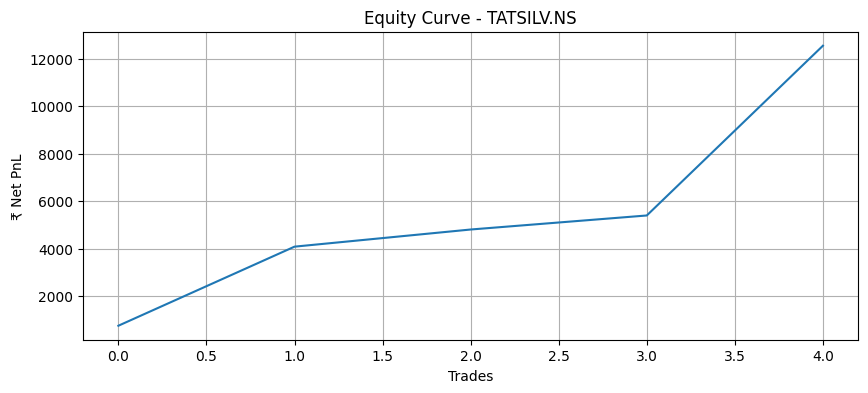

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# =====================
# CONFIGURATION
# =====================
SYMBOL = "TATSILV.NS"
INTERVAL = "5m"
PERIOD = "5d"

CAPITAL = 100000
RISK_PERCENT = 0.01
STOPLOSS_PERCENT = 0.01
DROP_BUY = 0.001
RISE_SELL = 0.006

# =====================
# FETCH REAL-TIME DATA
# =====================
print("Fetching live market data...")

df = yf.download(
    SYMBOL,
    interval=INTERVAL,
    period=PERIOD,
    progress=False,
    auto_adjust=False
)

if df.empty:
    raise Exception("No data fetched. Check symbol or internet connection.")

# ===== FIX MULTI-INDEX COLUMN ISSUE =====
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.reset_index()

# Standardize column names safely
df.columns = [str(c).lower() for c in df.columns]

# Check correct time column name
if "datetime" in df.columns:
    df.rename(columns={"datetime": "time"}, inplace=True)
elif "date" in df.columns:
    df.rename(columns={"date": "time"}, inplace=True)

# Keep only required columns
df = df[["time", "close"]]

# =====================
# CHARGES (INDIAN INTRADAY)
# =====================
def intraday_charges(buy_price, sell_price, qty):
    buy_value = buy_price * qty
    sell_value = sell_price * qty
    turnover = buy_value + sell_value

    brokerage = 40
    stt = sell_value * 0.00025
    exchange = turnover * 0.0000322
    sebi = turnover * 0.000001
    stamp = buy_value * 0.00003
    gst = 0.18 * (brokerage + exchange + sebi)

    return brokerage + stt + exchange + sebi + stamp + gst

# =====================
# POSITION SIZING
# =====================
def calculate_qty(price):
    risk_amount = CAPITAL * RISK_PERCENT
    sl_amount = price * STOPLOSS_PERCENT
    return max(int(risk_amount / sl_amount), 1)

# =====================
# BACKTEST ENGINE
# =====================
def backtest(df):

    trades = []
    position = None
    entry_price = 0
    qty = 0

    last_price = df.iloc[0]["close"]

    for i in range(1, len(df)):
        price = df.iloc[i]["close"]
        current_time = df.iloc[i]["time"]

        # ENTRY
        if position is None:
            if price <= last_price * (1 - DROP_BUY):
                entry_price = price
                qty = calculate_qty(price)
                entry_time = current_time
                position = "LONG"

        # EXIT
        elif position == "LONG":
            if price >= entry_price * (1 + RISE_SELL):
                gross = (price - entry_price) * qty
                charges = intraday_charges(entry_price, price, qty)
                net = gross - charges

                trades.append({
                    "entry_time": entry_time,
                    "exit_time": current_time,
                    "buy_price": round(entry_price, 2),
                    "sell_price": round(price, 2),
                    "quantity": qty,
                    "net_pnl": round(net, 2)
                })

                position = None

        last_price = price

    return pd.DataFrame(trades)

# =====================
# RUN STRATEGY
# =====================
results = backtest(df)

if results.empty:
    print("No trades executed.")
else:
    print("\n===== TRADE DETAILS =====")
    print(results.to_string(index=False))

# =====================
# PERFORMANCE SUMMARY
# =====================
def performance(trades):

    if trades.empty:
        print("No trades to analyze.")
        return

    total = trades["net_pnl"].sum()
    wins = trades[trades["net_pnl"] > 0]
    losses = trades[trades["net_pnl"] <= 0]

    win_rate = len(wins) / len(trades) * 100
    max_drawdown = trades["net_pnl"].cumsum().min()

    print("\n===== PERFORMANCE SUMMARY =====")
    print("Total Trades:", len(trades))
    print("Winning Trades:", len(wins))
    print("Losing Trades:", len(losses))
    print("Win Rate: {:.2f}%".format(win_rate))
    print("Net PnL: ₹ {:.2f}".format(total))
    print("Max Drawdown: ₹ {:.2f}".format(max_drawdown))

performance(results)

# =====================
# EQUITY CURVE
# =====================
if not results.empty:
    equity = results["net_pnl"].cumsum()
    plt.figure(figsize=(10, 4))
    plt.plot(equity)
    plt.title(f"Equity Curve - {SYMBOL}")
    plt.xlabel("Trades")
    plt.ylabel("₹ Net PnL")
    plt.grid(True)
    plt.show()